In [1]:
# Import libraries and list files

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm import tqdm

In [2]:
!pip install seaborn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_dataframe(df, columna='value'):
    # 1. Estadísticas descriptivas detalladas
    stats = df[columna].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    print("--- Estadísticas de la columna Value ---")
    print(stats)
    
    # 2. Conteo de ceros exactos
    ceros = (df[columna] == 0).sum()
    pct_ceros = (ceros / len(df)) * 100
    print(f"\nCeros absolutos: {ceros} ({pct_ceros:.2f}%)")
    
    # 3. Visualización dual
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Histograma con KDE (línea de densidad)
    sns.histplot(df[columna], bins=100, kde=True, ax=ax1, color='teal')
    ax1.set_title('Distribución Global (Histograma)')
    
    # Boxplot para ver los "Outliers" (los famosos 152 y -152)
    sns.boxplot(x=df[columna], ax=ax2, color='coral')
    ax2.set_title('Detección de Valores Extremos (Boxplot)')
    
    plt.tight_layout()
    plt.show()

# Uso:
# analizar_dataframe(mi_dataframe)

In [4]:
df00 = pd.read_csv("lc0_all_fens.csv")
df01 = pd.read_csv("lc0_normal_fens.csv")
df02 = pd.read_csv("lc0_middlegame_fens_move_value.csv")
df02

/tmp/ipykernel_551/1063312025.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df00 = pd.read_csv("lc0_all_fens.csv")
/tmp/ipykernel_551/1063312025.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df01 = pd.read_csv("lc0_normal_fens.csv")


,FEN,move,value
0,rn1k1b1r/pbpp1p1p/1p2p3/7B/3PP2q/P1N2Q2/1PP2PP...,e1c1,-0.8943
1,rn1qk3/ppp2pp1/3bpnp1/8/3PN3/3B4/PPP2PPr/R1BQK...,h1h2,0.0934
2,rn1qk3/ppp2pp1/3bpnp1/8/3PN3/3B4/PPP1KPP1/R1B4...,f6e4,-0.1072
3,r2q4/ppp1kppQ/2nbpnp1/6B1/3PN3/3B4/PPP1KPP1/R7...,c6d4,0.2060
4,r3q3/ppp1kppQ/3bpnp1/6B1/3nN3/3B4/PPPK1PP1/R7 ...,h7g7,0.5747
...,...,...,...
695450,2n2r1k/3b1Bp1/p2p3p/1p2p3/1P2P3/P2PPQPq/7N/5RK...,f3g2,-0.2139
695451,5r1k/3bnBp1/p2p3p/1p2p3/1P2P3/P2PPQPq/6RN/6K1 ...,d7e8,0.2282
695452,4b2k/4n1p1/p2pB2p/1p2p3/1P2P3/P2PPrPq/6RN/6K1 ...,e6h3,-0.5315
695453,3R4/6pk/p3B1np/1p1pp3/1P2b3/P2r2P1/8/5NK1 w - ...,e6g8,-0.3362


In [5]:
df0 = pd.concat([df00, df01, df02]) #, df01, df02])

converted = pd.to_numeric(df0['value'], errors="coerce")
df0["value"] = pd.to_numeric(df0["value"], errors="coerce")
df0 = df0.dropna(subset=["value"])
#print(df0.loc[converted.isna() & df0['value'].notna()])

df0

,FEN,move,value
0,r1b2rk1/ppp2pbp/3q1np1/n3p1B1/2B5/1Q3N2/PP1N1P...,b3a4,-0.7674
1,8/1pp2p2/6k1/4P2p/p1PR1K1P/2r2P2/6P1/8 w - - 0 33,c4c5,-0.7685
2,r2qk1nr/1b3pbp/n3p1p1/1pp1P3/p2PN3/2P2N2/PPB3P...,e4d6,0.9752
3,2b2rk1/5pp1/p2q1n1p/P2pn3/3N4/3BP1B1/2Q2PPP/Rr...,a1b1,0.4631
4,r2qkb1r/ppp2ppb/2n1p3/3n2PQ/3Pp3/2P4P/PP6/RNB1...,f1g2,-0.9470
...,...,...,...
695450,2n2r1k/3b1Bp1/p2p3p/1p2p3/1P2P3/P2PPQPq/7N/5RK...,f3g2,-0.2139
695451,5r1k/3bnBp1/p2p3p/1p2p3/1P2P3/P2PPQPq/6RN/6K1 ...,d7e8,0.2282
695452,4b2k/4n1p1/p2pB2p/1p2p3/1P2P3/P2PPrPq/6RN/6K1 ...,e6h3,-0.5315
695453,3R4/6pk/p3B1np/1p1pp3/1P2b3/P2r2P1/8/5NK1 w - ...,e6g8,-0.3362


--- Análisis del campo Value ---
Valor Máximo: 1.0
Valor Mínimo: -1.0
Valor Promedio: -0.05297527566698781
--- Estadísticas de la columna Value ---
count    4.134971e+06
mean    -5.297528e-02
std      6.024200e-01
min     -1.000000e+00
1%      -9.996000e-01
5%      -9.974000e-01
25%     -4.627000e-01
50%     -2.630000e-02
75%      2.717000e-01
95%      9.962000e-01
99%      9.996000e-01
max      1.000000e+00
Name: value, dtype: float64

Ceros absolutos: 7382 (0.18%)


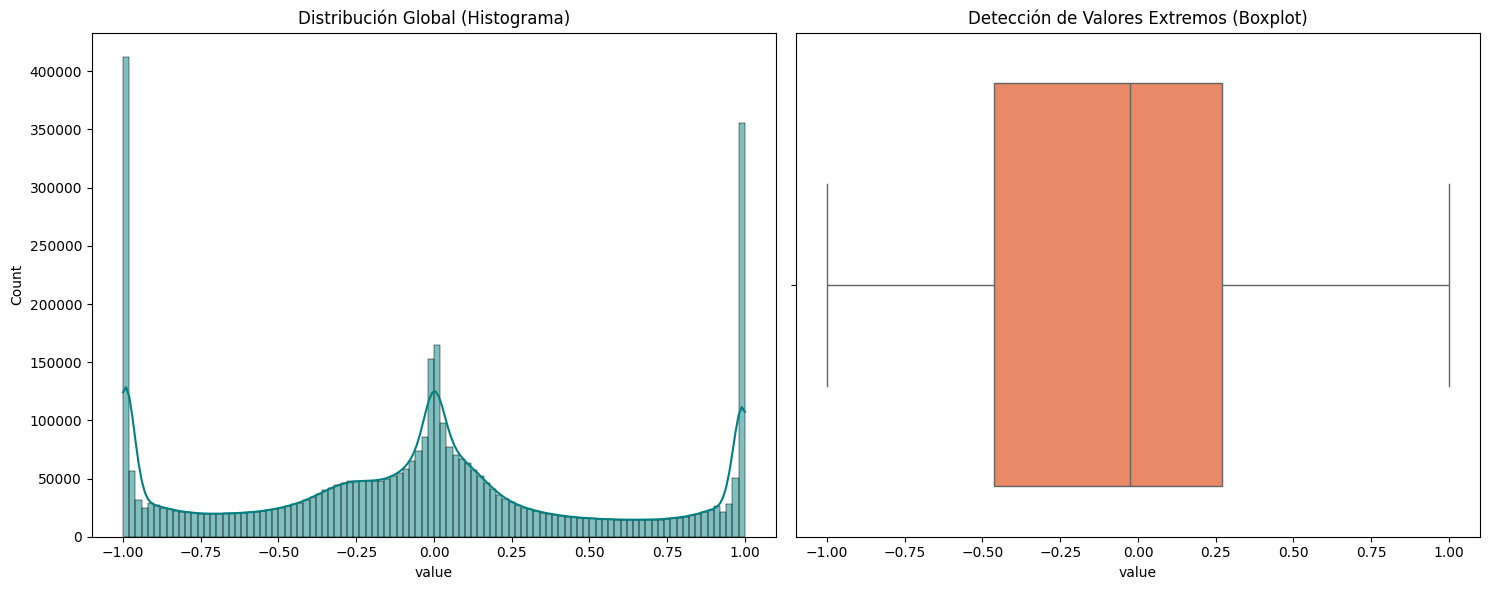

In [6]:
print("--- Análisis del campo Value ---")
print(f"Valor Máximo: {df0['value'].max()}")
print(f"Valor Mínimo: {df0['value'].min()}")
print(f"Valor Promedio: {df0['value'].mean()}")

analizar_dataframe(df0)

In [7]:
df_high = df0[abs(df0["value"]) > 0.99]

print(df_high)
print("Cantidad:", len(df_high))

df0[df0["value"] == 0]

                                                      FEN  move   value
5       r1bq1rk1/ppp2ppp/3p4/2b1p1NP/2Bnn3/4Q3/PPPP1PP...  d4c2  0.9975
9       r1b2b1r/pp2q1pk/2p3p1/3p2p1/4P2P/1Q4P1/PPPN1PB...  g1f3  0.9902
11      rnr3k1/4Qp2/b2p1P2/p2P2R1/1pq5/8/PP6/K3R3 b - ...  g8h8 -0.9927
12      8/1pk5/1p6/1PpR3p/P2b1pp1/5P1P/2P1K1P1/8 w - -...  f3g4  0.9956
15               8/1pp3p1/p2k4/8/PP6/2P2K2/8/8 w - - 1 43  f3e4 -0.9942
...                                                   ...   ...     ...
658784               8/8/5p1p/7P/2K1k1P1/8/8/8 b - - 2 47  e4f4  0.9924
659536  5R2/p6k/2p3p1/6P1/6P1/1P1r4/P2p2K1/3r1R2 w - -...  f1f7  0.9912
668805  4rk1r/pRQ3pp/4bn2/3q4/8/5N2/P4PPP/5RK1 w - - 5 22  c7g7  0.9909
672994         7k/4q2p/1p6/5Q2/3p2r1/5R2/7P/7K w - - 0 40  f5g4  0.9912
675858  r4rk1/p4p1p/1p1p1qpQ/6N1/3pP3/8/PPP3PP/R5K1 w ...  h6h7  0.9984

[643183 rows x 3 columns]
Cantidad: 643183


,FEN,move,value
150,8/8/7k/4R2P/1r6/6K1/8/8 w - - 45 78,e5e3,-0.0
301,8/6r1/6k1/1p2p1P1/1P2P3/2K5/8/6R1 w - - 2 41,g1f1,0.0
386,8/8/5kp1/8/6R1/7P/r7/6K1 b - - 1 61,f6f7,-0.0
558,8/k7/8/8/8/2K2bP1/1P6/8 b - - 1 51,a7b6,-0.0
1099,8/8/8/4k3/8/5P2/3K4/8 b - - 0 56,e5f5,-0.0
...,...,...,...
688808,8/8/4k3/6p1/4K3/5P2/8/8 w - - 2 47,e4d4,-0.0
688809,8/8/4k3/5P2/4K1p1/8/8/8 b - - 0 48,e6e7,-0.0
692900,rn2kb1Q/ppp4p/6pB/3p4/3P4/7b/PPP1NP1P/RN2Kq2 w...,e1d2,0.0
693205,8/7k/5pp1/p3p1pP/P3P1P1/4b2K/6B1/8 w - - 0 41,h5g6,0.0


In [8]:
def get_fullmove(fen):
    try:
        return int(fen.split()[-1])
    except (ValueError, AttributeError, IndexError):
        return None  # o np.nan

df0["fullmove"] = df0["FEN"].apply(get_fullmove)
df0 = df0[df0["fullmove"].notna()]
df_filtered = df0[
    ~((df0["fullmove"] > 100) & (df0["value"].abs() < 0.05))
]

replacement_moves = ['e2e4', 'c2c4', 'g1f3']
mask = (df_filtered['fullmove'] == 1) & (df_filtered['move'] == 'd2d4')
idx_to_replace = df_filtered[mask].index

# Tomamos un 50% al azar de estas filas
n_replace = int(len(idx_to_replace) * 0.5)
replace_indices = np.random.choice(idx_to_replace, size=n_replace, replace=False)

# Elegimos movimientos de reemplazo al azar
#df_filtered.loc[replace_indices, 'move'] = np.random.choice(replacement_moves, size=n_replace, replace=True)

df_filtered.loc[replace_indices, 'move'] = pd.Series(
    np.random.choice(replacement_moves, size=n_replace, replace=True), 
    index=replace_indices
)

df_filtered

,FEN,move,value,fullmove
0,r1b2rk1/ppp2pbp/3q1np1/n3p1B1/2B5/1Q3N2/PP1N1P...,b3a4,-0.7674,14.0
1,8/1pp2p2/6k1/4P2p/p1PR1K1P/2r2P2/6P1/8 w - - 0 33,c4c5,-0.7685,33.0
2,r2qk1nr/1b3pbp/n3p1p1/1pp1P3/p2PN3/2P2N2/PPB3P...,e4d6,0.9752,13.0
3,2b2rk1/5pp1/p2q1n1p/P2pn3/3N4/3BP1B1/2Q2PPP/Rr...,a1b1,0.4631,21.0
4,r2qkb1r/ppp2ppb/2n1p3/3n2PQ/3Pp3/2P4P/PP6/RNB1...,f1g2,-0.9470,11.0
...,...,...,...,...
695450,2n2r1k/3b1Bp1/p2p3p/1p2p3/1P2P3/P2PPQPq/7N/5RK...,f3g2,-0.2139,27.0
695451,5r1k/3bnBp1/p2p3p/1p2p3/1P2P3/P2PPQPq/6RN/6K1 ...,d7e8,0.2282,28.0
695452,4b2k/4n1p1/p2pB2p/1p2p3/1P2P3/P2PPrPq/6RN/6K1 ...,e6h3,-0.5315,30.0
695453,3R4/6pk/p3B1np/1p1pp3/1P2b3/P2r2P1/8/5NK1 w - ...,e6g8,-0.3362,37.0


In [9]:
df_starts = df_filtered[(df_filtered["fullmove"] == 2)]
df_starts['move'].value_counts()

move
d7d5    3788
d2d4    2874
e2e4    2383
e7e5    2217
c2c4    1814
        ... 
b8a6       1
a5b4       1
e6d5       1
d8g5       1
d8b6       1
Name: count, Length: 92, dtype: int64

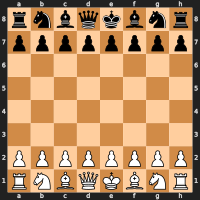

In [10]:
import chess
import chess.svg
from IPython.display import display, SVG

# Define un FEN de ejemplo (posición inicial)
fen_example = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"

# Crea un objeto de tablero de ajedrez
board = chess.Board(fen=fen_example)

# Muestra el tablero en formato SVG (gráficamente en el notebook)
svg_board = chess.svg.board(board=board, size=200)
display(SVG(svg_board))

In [11]:
!pip install python-chess

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [12]:

# Convert board in matrix of the pieces of some type. 
def board_to_matrix(board, piece_type):
    piece_map = board.piece_map()
    matrix = np.zeros((8,8))

    for square, piece in piece_map.items():
        # chess.square_rank y chess.square_file return row and column
        rank = chess.square_rank(square)
        file = chess.square_file(square)
        if(piece.piece_type == piece_type):
            matrix[7 - rank, file] = (-1 if piece.color == chess.BLACK else 1) * 1 # piece.piece_type 
    return matrix

# Convert board in 13x8x8 with every type/color piece in a layer and a layer for turn.
def board2rep(board):
    pieces = [1,2,3,4,5,6]
    layers = []
    for piece in pieces:
        matrix = board_to_matrix(board,piece)
        white_matrix = np.where(matrix == 1, 1, 0)
        black_matrix = np.where(matrix == -1, 1, 0)
        
        layers.append(white_matrix)
        layers.append(black_matrix)
    if board.turn:
        color_matrix = np.ones((8,8))
        layers.append(color_matrix)
    else:
        color_matrix = np.zeros((8,8))
        layers.append(color_matrix)
        
    board_rep = np.stack(layers)
    board_rep = board_rep.astype(bool)
    return board_rep


    # Definition of the moves as a dictionary of tuples 
codes, i = {}, 0
    # All 56 regular moves of a Queen or other normal pieces
for nSquares in range(1,8):
    for direction in [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]:
        codes[(nSquares*direction[0],nSquares*direction[1])] = i
        i += 1
    # 8 Knight moves
codes[(1,2)], i = i,  i+1
codes[(2,1)], i = i,  i+1
codes[(2,-1)], i = i,  i+1
codes[(1,-2)], i = i,  i+1
codes[(-1,-2)], i = i,  i+1
codes[(-2,-1)], i = i,  i+1
codes[(-2,1)], i = i,  i+1
codes[(-1,2)], i = i,  i+1 

    # We avoid pawn promotion because are the same moves and we are looking for 1 best move. 

# Extract and convert legal moves to the 64x8x8 matrix. 
def legal_moves_to_64_8_8(board):

    legal_moves = list(board.legal_moves)
    
    # Apply the function to each move in the list
    extracted_moves = [[
        [chess.square_rank(m.from_square),chess.square_file(m.from_square)], 
         (chess.square_file(m.to_square) - chess.square_file(m.from_square), chess.square_rank(m.to_square) - chess.square_rank(m.from_square))
    ] for m in legal_moves]

    # Creation of the array and apply the moves:
    array6488 = np.zeros((64,8,8))
    for em in extracted_moves:
        array6488[codes[em[1]], 7-em[0][0], em[0][1]] = 1
        
    array6488 = array6488.astype(bool)
    return  array6488

# This function is to convert to a number. See below the example to understand this complicated code:
def uci_to_number(uci_move):
    m = chess.Move.from_uci(uci_move)
    move_code = codes[(chess.square_file(m.to_square) - chess.square_file(m.from_square), 
                   chess.square_rank(m.to_square) - chess.square_rank(m.from_square))]
    pos = np.ravel_multi_index(
        multi_index=((move_code, 7-chess.square_rank(m.from_square), chess.square_file(m.from_square))),
        dims=(64,8,8)
    )
    return pos


def concat_fen_legal(fen):
    board = chess.Board(fen)
    fen_matrix = board2rep(board)
    legal_moves = legal_moves_to_64_8_8(board)
    fen_matrix_legal_moves = np.concatenate((fen_matrix,legal_moves),0)
    fen_matrix_legal_moves = fen_matrix_legal_moves.reshape(-1)
    return fen_matrix_legal_moves

def normalize_perspective(fen, move_uci):
    """
    Normaliza el FEN y el movimiento si el turno es de las negras.
    """
    board = chess.Board(fen)
    if board.turn == chess.BLACK:
        # Voltear tablero
        flipped_board = board.mirror()
        # Voltear movimiento
        move = chess.Move.from_uci(move_uci)
        flipped_move = chess.Move(
            chess.square_mirror(move.from_square),
            chess.square_mirror(move.to_square),
            promotion=move.promotion
        )
        return flipped_board.fen(), flipped_move.uci()
    return fen, move_uci

def converter(df_mates, file_size=1000):
    dfs = []

    for start in tqdm(range(0, len(df_mates), file_size)):
        # Extraemos el chunk actual
        chunk = df_mates.iloc[start:start + file_size].copy()

        # Aplicamos la normalización sobre el chunk antes de convertir a tensores
        # Esto nos permite ver el progreso y no saturar la RAM
        chunk[['fen', 'move']] = chunk.apply(
            lambda r: pd.Series(normalize_perspective(r['FEN'], r['move'])), 
            axis=1
        )

        df_chunk = pd.DataFrame({
            # Ahora concat_fen_legal recibe el FEN ya volteado si era negro
            'board': chunk['FEN'].apply(concat_fen_legal),
            # uci_to_number recibe el movimiento ya invertido si era negro
            'best': chunk['move'].apply(uci_to_number),
            'fen_original': chunk['FEN'],
            'best_uci': chunk['move'],
            #'original_best_uci': chunk['move'],
            'value': chunk['value']
        })

        dfs.append(df_chunk)

    return pd.concat(dfs, ignore_index=True)


df_mates = df_filtered

df_mates_converted = converter(df_mates)

#df_mates_converted.to_parquet('lc0_converted.parquet_v2.gzip', compression='gzip')
        

100%|██████████| 4080/4080 [20:57<00:00,  3.25it/s]


In [13]:
df_mates_converted

,board,best,fen_original,best_uci,value
0,"[False, False, False, False, False, False, Fal...",489,r1b2rk1/ppp2pbp/3q1np1/n3p1B1/2B5/1Q3N2/PP1N1P...,b3a4,-0.7674
1,"[False, False, False, False, False, False, Fal...",34,8/1pp2p2/6k1/4P2p/p1PR1K1P/2r2P2/6P1/8 w - - 0 33,c4c5,-0.7685
2,"[False, False, False, False, False, False, Fal...",4068,r2qk1nr/1b3pbp/n3p1p1/1pp1P3/p2PN3/2P2N2/PPB3P...,e4d6,0.9752
3,"[False, False, False, False, False, False, Fal...",184,2b2rk1/5pp1/p2q1n1p/P2pn3/3N4/3BP1B1/2Q2PPP/Rr...,a1b1,0.4631
4,"[False, False, False, False, False, False, Fal...",125,r2qkb1r/ppp2ppb/2n1p3/3n2PQ/3Pp3/2P4P/PP6/RNB1...,f1g2,-0.9470
...,...,...,...,...,...
4079402,"[False, False, False, False, False, False, Fal...",237,2n2r1k/3b1Bp1/p2p3p/1p2p3/1P2P3/P2PPQPq/7N/5RK...,f3g2,-0.2139
4079403,"[False, False, False, False, False, False, Fal...",243,5r1k/3bnBp1/p2p3p/1p2p3/1P2P3/P2PPQPq/6RN/6K1 ...,d2e1,0.2282
4079404,"[False, False, False, False, False, False, Fal...",1236,4b2k/4n1p1/p2pB2p/1p2p3/1P2P3/P2PPrPq/6RN/6K1 ...,e6h3,-0.5315
4079405,"[False, False, False, False, False, False, Fal...",596,3R4/6pk/p3B1np/1p1pp3/1P2b3/P2r2P1/8/5NK1 w - ...,e6g8,-0.3362


In [14]:
import pyarrow as pa
import pyarrow.parquet as pq

chunk_size = 200_000

# usar el primer chunk REAL para definir el schema
first_chunk = df_mates_converted.iloc[:chunk_size]
table = pa.Table.from_pandas(first_chunk, preserve_index=False)

writer = pq.ParquetWriter(
    "lc0_diverse_converted.parquet",
    table.schema,
    compression="snappy"
)

# escribir el primer chunk
writer.write_table(table)

# escribir el resto
for i in range(chunk_size, len(df_mates_converted), chunk_size):
    print(i)
    chunk = df_mates_converted.iloc[i:i + chunk_size]
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    writer.write_table(table)

writer.close()


200000
400000
600000
800000
1000000
1200000
1400000
1600000
1800000
2000000
2200000
2400000
2600000
2800000
3000000
3200000
3400000
3600000
3800000
4000000


In [ ]:
df['fen'].value_counts()[lambda x: x > 4]




In [ ]:
df[df['fen'] == "r1bq1rk1/pp2n1bp/2n1ppp1/3pP3/P2P4/N2B1N2/1P3PPP/R1BQ1RK1 w - - 0 11"]


In [15]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

INPUT = "lc0_diverse_converted.parquet"
OUTPUT = "lc0_diverse_converted_chunk_shuffled.parquet"

RANDOM_STATE = 42

pq_file = pq.ParquetFile(INPUT)

writer = None
rng = np.random.default_rng(RANDOM_STATE)

row_groups = list(range(pq_file.num_row_groups))
rng.shuffle(row_groups)

for i in row_groups:
    print(i)
    table = pq_file.read_row_group(i)
    df = table.to_pandas()

    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    if writer is None:
        writer = pq.ParquetWriter(
            OUTPUT,
            table.schema,
            compression="snappy"
        )

    writer.write_table(pa.Table.from_pandas(df, preserve_index=False))

writer.close()


16
10
15
20
12
14
7
6
9
3
0
17
5
11
19
2
4
18
1
13
8


In [ ]:
import pandas as pd

df = pd.read_parquet("train-00000-of-00003.parquet")

print(df.head())


In [ ]:
df

In [ ]:
df["Rating"].describe()

In [ ]:
df_hard = df[(df["Rating"] > 1800) & (df["Rating"] < 2600)]


In [ ]:
df_hard

In [ ]:
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("mate" in x for x in t))]
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("crushing" in x for x in t))]
df_hard = df_hard[~df_hard["Themes"].apply(lambda t: any("oneMove" in x for x in t))]
df_hard

In [ ]:
df_fen = df_hard['FEN']

In [ ]:
df_fen

In [ ]:
df_fen.to_csv("puzzles_1800_2600.csv", index=False)

In [ ]:
df_fen[19]

In [ ]:
df = pd.read_json('dataset_all.json')
df

In [ ]:
df_fens = df['fen']

In [ ]:
df_fens.to_csv("dataset_all_nomoves.csv", index=False)